In [89]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql.functions import when, col, mean, sum, count, lit, trim, year, datediff, month, dayofmonth, weekofyear, max as spark_max, min as spark_min
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialiser une session Spark
spark = SparkSession.builder \
    .appName("Analyse E-commerce") \
    .config("spark.sql.debug.maxToStringFields", 1000) \
    .getOrCreate()

# Charger le fichier Excel
df_excel = pd.read_excel("Données_Ecommerce.xlsx")

# Sauvegarder en CSV
df_excel.to_csv("Données_Ecommerce.csv", index=False)

# Charger les données depuis un fichier CSV (après conversion de l'Excel)
df = spark.read.csv("Données_Ecommerce.csv", header=True, inferSchema=True)
#df = spark.read.option("header", True).option("delimiter", ";").csv("Données_Ecommerce.csv")

print(f"""
****************************************************************
********************PREPARATION DES DONNEES*********************
****************************************************************
""")
# Affichage des premières lignes pour vérifier les données
print("Aperçu des données :")
df.show(5)

# Supposons que les promotions sont indiquées par une colonne "Promotion" (1 = promotion, 0 = pas de promotion)
# Calculer la moyenne du prix unitaire
mean_price = df.agg(F.mean("Prix Unitaire (€)").alias("mean_price")).collect()[0]["mean_price"]

# Ajouter la colonne "Promotion" en fonction de la moyenne
df = df.withColumn("Promotion", F.when(F.col("Prix Unitaire (€)") < mean_price, 1).otherwise(0))
print("Aperçu des données avec la nouvelle colonne :")
df.show(5)

# Structuration des données
print(f"""
Structuration des données:
- Créer un DataFrame avec des colonnes clairement définies.
- Utiliser des types de données appropriés pour chaque colonne.
NB: Possibilité de creer de différentes tables: clients (Client_ID, Sexe, Âge, Localisation) transactions (Client_ID, Catégorie, Produit, Prix Unitaire, Quantité, Montant Total, Date Achat) et de les regrouper par catégorie de produit ou par localisation pour analyser les tendances.
""")

# Variables importantes
print(f"""
Variables importantes:
- Client_ID (identifiant unique)
- Sexe (qualitative)
- Âge (quantitative continue)
- Localisation (qualitative)
- Catégorie (qualitative)
- Produit (qualitative)
- Prix Unitaire (€) (quantitative continue)
- Quantité (quantitative discrète)
- Montant Total (€) (quantitative continue)
- Date Achat (temporelle)
""")


****************************************************************
********************PREPARATION DES DONNEES*********************
****************************************************************

Aperçu des données :
+---------+-----+---+------------+------------+----------------+-----------------+--------+-----------------+----------+
|Client_ID| Sexe|Âge|Localisation|   Catégorie|         Produit|Prix Unitaire (€)|Quantité|Montant Total (€)|Date Achat|
+---------+-----+---+------------+------------+----------------+-----------------+--------+-----------------+----------+
|     2095|Homme| 38|        Lyon|      Livres|Livre de cuisine|           190.39|       3|           571.17|2023-03-23|
|     3919|Homme| 41|    Bordeaux|Alimentation|        Chocolat|            173.9|       4|            695.6|2023-05-02|
|     2184|Femme| 29|    Bordeaux|      Maison|  Machine à café|            40.46|       1|            40.46|2023-12-25|
|     3047|Femme| 45|       Lille|Électronique|    Casqu

In [90]:
print(f"""
****************************************************************
*********************NETTOYAGE DES DONNEES**********************
****************************************************************
""")
# Recherche des valeurs manquantes
print("Aperçu des valeurs manquantes:")
df_missing_values = df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns])
df_missing_values.show()

# Nombre de lignes avant la suppression des doublons
initial_count = df.count()

# Supprimer les doublons
df_no_duplicates = df.dropDuplicates()

# Nombre de lignes après la suppression des doublons
final_count = df_no_duplicates.count()

# Vérifier s'il y a des doublons
if initial_count > final_count:
    print(f"Il y a {initial_count - final_count} doublons dans le DataFrame.")
else:
    print(f"Il n'y a pas de doublons dans le DataFrame.\n")


****************************************************************
*********************NETTOYAGE DES DONNEES**********************
****************************************************************

Aperçu des valeurs manquantes:
+---------+----+---+------------+---------+-------+-----------------+--------+-----------------+----------+---------+
|Client_ID|Sexe|Âge|Localisation|Catégorie|Produit|Prix Unitaire (€)|Quantité|Montant Total (€)|Date Achat|Promotion|
+---------+----+---+------------+---------+-------+-----------------+--------+-----------------+----------+---------+
|        0|   0|  0|           0|        0|      0|                0|       0|                0|         0|        0|
+---------+----+---+------------+---------+-------+-----------------+--------+-----------------+----------+---------+

Il n'y a pas de doublons dans le DataFrame.



In [91]:
print(f"""
****************************************************************
***********************ANALYSE DE DONNEES***********************
****************************************************************
""")

# Statistiques descriptives
print("Statistiques descriptives pour les colonnes numériques :")
df.select("Âge", "Prix Unitaire (€)", "Quantité", "Montant Total (€)").describe().show()

# Ventes totales par catégorie
print("Ventes totales par catégorie :")
df_grouped_category = df.groupBy("Catégorie").agg(
    sum("Montant Total (€)").alias("Total_Ventes"),
    count("Client_ID").alias("Nombre_Transactions")
).orderBy("Total_Ventes", ascending=False)
df_grouped_category.show()

# Ventes totales par localisation
print("Ventes totales par localisation :")
df_grouped_location = df.groupBy("Localisation").agg(
    sum("Montant Total (€)").alias("Total_Ventes"),
    count("Client_ID").alias("Nombre_Transactions")
).orderBy("Total_Ventes", ascending=False)
df_grouped_location.show()

# Ventes totales par sexe
print("Ventes totales par sexe :")
df_grouped_gender = df.groupBy("Sexe").agg(
    sum("Montant Total (€)").alias("Total_Ventes"),
    count("Client_ID").alias("Nombre_Transactions")
).orderBy("Total_Ventes", ascending=False)
df_grouped_gender.show()

# Produits les plus vendus
print("Produits les plus vendus :")
top_products = df.groupBy("Produit").agg(
    sum("Quantité").alias("Total_Quantité_Vendue"),
    sum("Montant Total (€)").alias("Total_Ventes")
).orderBy("Total_Quantité_Vendue", ascending=False)
top_products.show(10)

# Produits les moins performants
print("Produits les moins performants :")
bottom_products = df.groupBy("Produit").agg(
    sum("Quantité").alias("Total_Quantité_Vendue"),
    sum("Montant Total (€)").alias("Total_Ventes")
).orderBy("Total_Quantité_Vendue", ascending=True)
bottom_products.show(10)


****************************************************************
***********************ANALYSE DE DONNEES***********************
****************************************************************

Statistiques descriptives pour les colonnes numériques :
+-------+------------------+------------------+------------------+------------------+
|summary|               Âge| Prix Unitaire (€)|          Quantité| Montant Total (€)|
+-------+------------------+------------------+------------------+------------------+
|  count|             10000|             10000|             10000|             10000|
|   mean|           43.4384|102.39821699999962|            2.4927|255.72834299999872|
| stddev|14.919244747184177| 56.64820146804185|1.1188708134497543|193.10435715674507|
|    min|                18|              5.02|                 1|              5.05|
|    max|                69|            199.99|                 4|             799.4|
+-------+------------------+------------------+-----------

In [92]:
# Évolution des ventes par catégorie
print("Évolution des ventes par catégorie :")
df = df.withColumn("Année", year(col("Date Achat"))) \
       .withColumn("Mois", month(col("Date Achat"))) \
       .withColumn("Semaine", weekofyear(col("Date Achat")))

sales_by_category = df.groupBy("Catégorie", "Année", "Mois").agg(
    sum("Montant Total (€)").alias("Total_Ventes")
).orderBy("Catégorie", "Année", "Mois")
sales_by_category.show(20)

# Analyse des pics de ventes saisonniers
print("Pics de ventes saisonniers :")
seasonal_sales = df.groupBy("Année", "Mois").agg(
    sum("Montant Total (€)").alias("Total_Ventes")
).orderBy("Année", "Mois")
seasonal_sales.show(20)

# Produits en croissance et en déclin
# Calculer les ventes par produit et par mois
product_growth = df.groupBy("Produit", "Année", "Mois").agg(
    sum("Montant Total (€)").alias("Total_Ventes")
).orderBy("Produit", "Année", "Mois")

# Convertir en Pandas DataFrame pour l'analyse
product_growth_pd = product_growth.toPandas()

# Calculer la croissance mensuelle des ventes par produit
product_growth_pd["Croissance"] = product_growth_pd.groupby("Produit")["Total_Ventes"].pct_change()

# Afficher les produits en croissance et en déclin
print("Produits en croissance :")
print(product_growth_pd[product_growth_pd["Croissance"] > 0].sort_values("Croissance", ascending=False).head(10))

print(f"\nProduits en déclin :")
print(product_growth_pd[product_growth_pd["Croissance"] < 0].sort_values("Croissance", ascending=True).head(10))

Évolution des ventes par catégorie :
+------------+-----+----+------------------+
|   Catégorie|Année|Mois|      Total_Ventes|
+------------+-----+----+------------------+
|Alimentation| 2023|   1|30963.680000000008|
|Alimentation| 2023|   2|23361.640000000003|
|Alimentation| 2023|   3|26534.920000000006|
|Alimentation| 2023|   4|30117.659999999993|
|Alimentation| 2023|   5|25510.269999999997|
|Alimentation| 2023|   6|31843.479999999996|
|Alimentation| 2023|   7|33371.220000000016|
|Alimentation| 2023|   8| 35302.62999999998|
|Alimentation| 2023|   9|26578.920000000002|
|Alimentation| 2023|  10| 33551.30000000002|
|Alimentation| 2023|  11|25244.730000000003|
|Alimentation| 2023|  12|26181.149999999994|
|      Beauté| 2023|   1|26283.309999999994|
|      Beauté| 2023|   2|           28387.0|
|      Beauté| 2023|   3|33484.469999999994|
|      Beauté| 2023|   4| 38378.30999999999|
|      Beauté| 2023|   5| 31813.08999999999|
|      Beauté| 2023|   6|          20760.87|
|      Beauté| 202


****************************************************************
*************************VISUALISATIONS*************************
****************************************************************



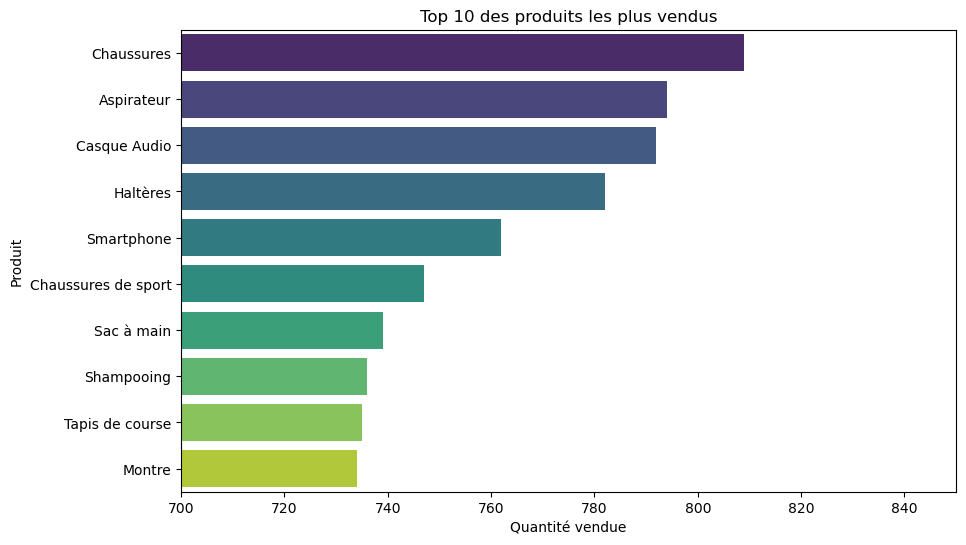

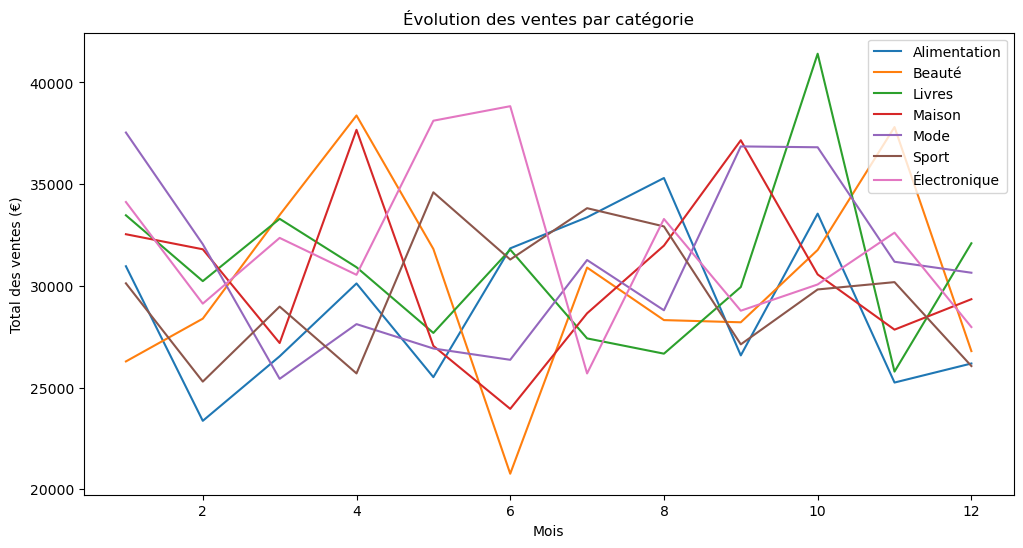

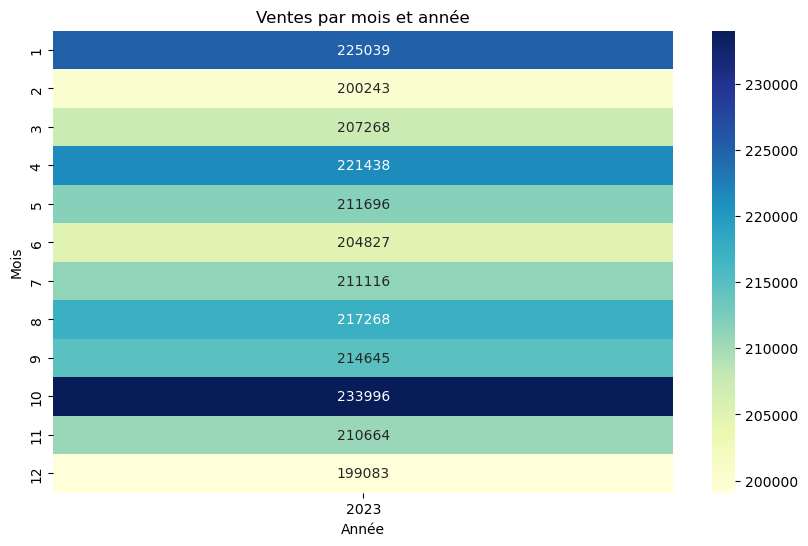

In [93]:
print(f"""
****************************************************************
*************************VISUALISATIONS*************************
****************************************************************
""")

# Histogramme des produits les plus vendus
top_products_pd = top_products.limit(10).toPandas()
plt.figure(figsize=(10, 6))
sns.barplot(x="Total_Quantité_Vendue", y="Produit", data=top_products_pd, palette="viridis", hue="Produit")
plt.xlim(700, 850)  # L'axe x commence à 500 et se limite à 850
plt.title("Top 10 des produits les plus vendus")
plt.xlabel("Quantité vendue")
plt.ylabel("Produit")
plt.show()

# Courbe des ventes par catégorie
sales_by_category_pd = sales_by_category.toPandas()
plt.figure(figsize=(12, 6))
for category in sales_by_category_pd["Catégorie"].unique():
    category_data = sales_by_category_pd[sales_by_category_pd["Catégorie"] == category]
    plt.plot(category_data["Mois"], category_data["Total_Ventes"], label=category)
plt.title("Évolution des ventes par catégorie")
plt.xlabel("Mois")
plt.ylabel("Total des ventes (€)")
plt.legend()
plt.show()

# Heatmap des ventes par "Année", "Mois" et "Total_Ventes"
heatmap_data = df.groupBy("Année", "Mois").agg(
    sum("Montant Total (€)").alias("Total_Ventes")
).orderBy("Année", "Mois").toPandas()

# Pivot des données pour la heatmap
heatmap_data_pivot = heatmap_data.pivot(index="Mois", columns="Année", values="Total_Ventes")

# Créer la figure de la heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data_pivot, annot=True, fmt=".0f", cmap="YlGnBu")

# Afficher la heatmap
plt.title("Ventes par mois et année")
plt.xlabel("Année")
plt.ylabel("Mois")
plt.show()

In [94]:
print(f"""
****************************************************************
*******************PROMOTIONS ET FIDELISATION*******************
****************************************************************
""")

# Impact des promotions sur les ventes
# Identifier les produits qui réagissent le mieux aux réductions
print("Identification des produits qui réagissent le mieux aux réductions :")
product_promotion_impact = df.groupBy("Produit", "Promotion").agg(
    sum("Quantité").alias("Total_Quantité_Vendue"),
    sum("Montant Total (€)").alias("Total_Ventes")
).orderBy("Produit", "Promotion")
product_promotion_impact.show(20)

# Effets de cannibalisation entre produits
# Comparer les ventes des produits similaires pendant les promotions
print("Comparaison des ventes des produits similaires pendant les promotions :")
similar_products = ["Livre de cuisine", "Chocolat", "Machine à café"]  # Exemple de produits similaires
cannibalization_analysis = df.filter(col("Produit").isin(similar_products)).groupBy("Produit", "Promotion").agg(
    sum("Quantité").alias("Total_Quantité_Vendue")
).orderBy("Produit", "Promotion")
cannibalization_analysis.show()

# Impact des remises sur le chiffre d'affaires global
print("Impact des remises sur le chiffre d'affaires global :")
promotion_impact_global = df.groupBy("Promotion").agg(
    sum("Montant Total (€)").alias("Total_Ventes")
).orderBy("Promotion")
promotion_impact_global.show()


****************************************************************
*******************PROMOTIONS ET FIDELISATION*******************
****************************************************************

Identification des produits qui réagissent le mieux aux réductions :
+-------------------+---------+---------------------+------------------+
|            Produit|Promotion|Total_Quantité_Vendue|      Total_Ventes|
+-------------------+---------+---------------------+------------------+
|         Aspirateur|        0|                  400|62775.649999999994|
|         Aspirateur|        1|                  394|21735.030000000002|
|                 BD|        0|                  368|55867.080000000016|
|                 BD|        1|                  363|19103.020000000004|
|             Canapé|        0|                  313|           47610.4|
|             Canapé|        1|                  306|          18550.21|
|       Casque Audio|        0|                  423| 62767.46999999999|
|   

In [95]:
# Analyse de la fidélisation client

# Définir une fenêtre partitionnée par Client_ID
window_spec = Window.partitionBy("Client_ID").orderBy("Date Achat")

# Calculer la date du premier achat pour chaque client
df = df.withColumn("Premier_Achat", F.min("Date Achat").over(window_spec))

# Calculer la différence en jours entre chaque achat et le premier achat
df = df.withColumn("Jours_Depuis_Premier_Achat", F.datediff(F.col("Date Achat"), F.col("Premier_Achat")))

# Définir une période de rétention (par exemple, 30 jours)
retention_period = 30
df = df.withColumn("Client_Rétention", when(col("Jours_Depuis_Premier_Achat") <= retention_period, 1).otherwise(0))

# Calculer le taux de rétention
print("Taux de rétention :")
retention_rate = df.groupBy("Client_Rétention").agg(
    count("Client_ID").alias("Nombre_Clients")
).withColumn("Taux_Rétention", col("Nombre_Clients") / df.count())
retention_rate.show()

# Segmentation des clients par fréquence d'achat
# Calculer le nombre d'achats par client
client_frequency = df.groupBy("Client_ID").agg(
    count("Date Achat").alias("Nombre_Achats")
).orderBy("Nombre_Achats", ascending=False)

# Segmenter les clients en fonction de leur fréquence d'achat
client_frequency = client_frequency.withColumn("Segment", when(col("Nombre_Achats") >= 5, "Régulier")
                                               .when((col("Nombre_Achats") >= 2) & (col("Nombre_Achats") < 5), "Occasionnel")
                                               .otherwise("Nouveau"))
print("Segmentation des clients en fonction de leur fréquence d'achat :")
client_frequency.show()

# c. Panier moyen des clients réguliers vs nouveaux clients
# Joindre la fréquence d'achat avec les données de ventes
df_with_frequency = df.join(client_frequency, on="Client_ID", how="left")

# Calculer le panier moyen par segment
print("Panier moyen par segment :")
average_basket = df_with_frequency.groupBy("Segment").agg(
    (sum("Montant Total (€)") / sum("Quantité")).alias("Panier_Moyen")
).orderBy("Panier_Moyen", ascending=False)
average_basket.show()

Taux de rétention :
+----------------+--------------+--------------+
|Client_Rétention|Nombre_Clients|Taux_Rétention|
+----------------+--------------+--------------+
|               1|          4412|        0.4412|
|               0|          5588|        0.5588|
+----------------+--------------+--------------+

Segmentation des clients en fonction de leur fréquence d'achat :
+---------+-------------+--------+
|Client_ID|Nombre_Achats| Segment|
+---------+-------------+--------+
|     4377|           10|Régulier|
|     1165|            9|Régulier|
|     2320|            9|Régulier|
|     3209|            9|Régulier|
|     2347|            9|Régulier|
|     2065|            9|Régulier|
|     4092|            8|Régulier|
|     1269|            8|Régulier|
|     4723|            8|Régulier|
|     1515|            8|Régulier|
|     4551|            8|Régulier|
|     3428|            8|Régulier|
|     4128|            8|Régulier|
|     2057|            8|Régulier|
|     3444|            8|


****************************************************************
*************************VISUALISATIONS*************************
****************************************************************



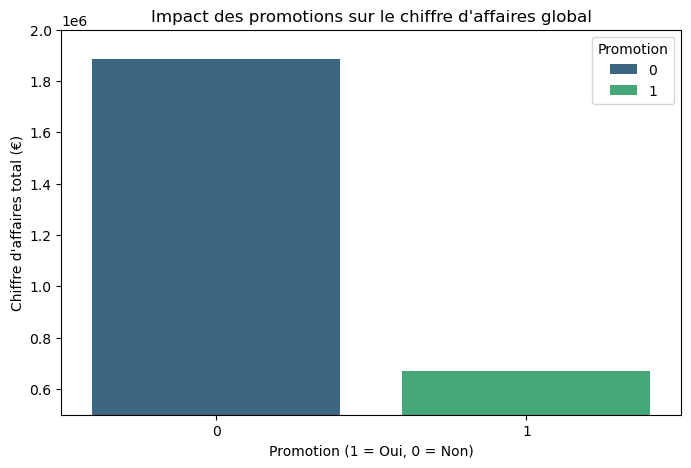

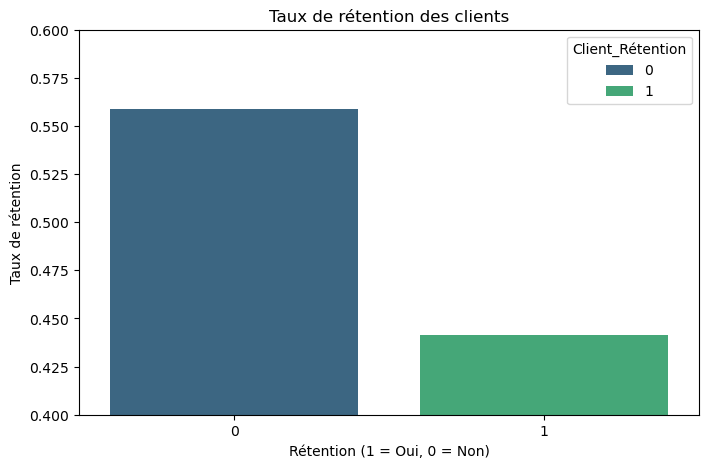

In [96]:
print(f"""
****************************************************************
*************************VISUALISATIONS*************************
****************************************************************
""")

# Graphiques d’évolution du chiffre d’affaires avant/après promotions
promotion_impact_global_pd = promotion_impact_global.toPandas()
plt.figure(figsize=(8, 5))
sns.barplot(x="Promotion", y="Total_Ventes", data=promotion_impact_global_pd, palette="viridis", hue="Promotion")
plt.ylim(500000, 2000000)  # L'axe x commence à 500 et se limite à 850
plt.title("Impact des promotions sur le chiffre d'affaires global")
plt.xlabel("Promotion (1 = Oui, 0 = Non)")
plt.ylabel("Chiffre d'affaires total (€)")
plt.show()

# Courbes de rétention des clients
retention_rate_pd = retention_rate.toPandas()
plt.figure(figsize=(8, 5))
sns.barplot(x="Client_Rétention", y="Taux_Rétention", data=retention_rate_pd, palette="viridis", hue="Client_Rétention")
plt.ylim(0.4, 0.6)  # L'axe x commence à 500 et se limite à 850
plt.title("Taux de rétention des clients")
plt.xlabel("Rétention (1 = Oui, 0 = Non)")
plt.ylabel("Taux de rétention")
plt.show()


In [103]:
print(f"""
****************************************************************
**************ANALYSE RFM & CLUSTERING K-MEANS******************
****************************************************************
""")

# Calcul des métriques RFM (Récence, Fréquence, Montant)
# Récence : Nombre de jours depuis le dernier achat
# Fréquence : Nombre total d'achats
# Montant : Montant total dépensé
rfm_data = df.groupBy("Client_ID").agg(
    datediff(lit("2023-12-31"), spark_max("Date Achat")).alias("Récence"),  # Date de fin fictive
    count("Date Achat").alias("Fréquence"),
    sum("Montant Total (€)").alias("Montant")
)

# Normalisation des données RFM
# Assembler les colonnes RFM en un vecteur
assembler = VectorAssembler(inputCols=["Récence", "Fréquence", "Montant"], outputCol="features")
rfm_data = assembler.transform(rfm_data)

# Standardiser les données
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(rfm_data)
rfm_data = scaler_model.transform(rfm_data)

# Appliquer K-Means pour segmenter les clients
kmeans = KMeans(k=4, seed=42, featuresCol="scaled_features", predictionCol="cluster")
model = kmeans.fit(rfm_data)
rfm_data = model.transform(rfm_data)

# Analyser les clusters
print("Visualisations des clusters :")
cluster_summary = rfm_data.groupBy("cluster").agg(
    spark_max("Récence").alias("Max_Récence"),
    spark_min("Récence").alias("Min_Récence"),
    spark_max("Fréquence").alias("Max_Fréquence"),
    spark_min("Fréquence").alias("Min_Fréquence"),
    spark_max("Montant").alias("Max_Montant"),
    spark_min("Montant").alias("Min_Montant")
).orderBy("cluster")
cluster_summary.show()

# Segmentation des clients
# Clients réguliers vs occasionnels
rfm_data = rfm_data.withColumn("Segment_Fréquence", when(col("Fréquence") >= 5, "Régulier")
                               .when((col("Fréquence") >= 2) & (col("Fréquence") < 5), "Occasionnel")
                               .otherwise("Nouveau"))

# Acheteurs impulsifs vs acheteurs rationnels
rfm_data = rfm_data.withColumn("Segment_Type_Achat", when(col("Montant") / col("Fréquence") > 100, "Rationnel")
                               .otherwise("Impulsif"))

# Clients sensibles aux promotions vs clients fidèles sans remises
promotion_sensitivity = df.groupBy("Client_ID").agg(
    (sum(when(col("Promotion") == 1, 1).otherwise(0)) / count("Date Achat")).alias("Taux_Promotion")
)
rfm_data = rfm_data.join(promotion_sensitivity, on="Client_ID", how="left")
rfm_data = rfm_data.withColumn("Segment_Promotion", when(col("Taux_Promotion") > 0.5, "Sensible_Promotions")
                               .otherwise("Fidèle_Sans_Remises"))


****************************************************************
**************ANALYSE RFM & CLUSTERING K-MEANS******************
****************************************************************

Visualisations des clusters :
+-------+-----------+-----------+-------------+-------------+------------------+-----------------+
|cluster|Max_Récence|Min_Récence|Max_Fréquence|Min_Fréquence|       Max_Montant|      Min_Montant|
+-------+-----------+-----------+-------------+-------------+------------------+-----------------+
|      0|        364|        156|            4|            1|           1475.76|             6.07|
|      1|        163|          3|            3|            1|            822.65|            11.11|
|      2|        268|          3|           10|            3|3741.4900000000002|646.1600000000001|
|      3|        273|          3|            6|            2|1653.6399999999999|            166.1|
+-------+-----------+-----------+-------------+-------------+------------------+


****************************************************************
*************************VISUALISATIONS*************************
****************************************************************



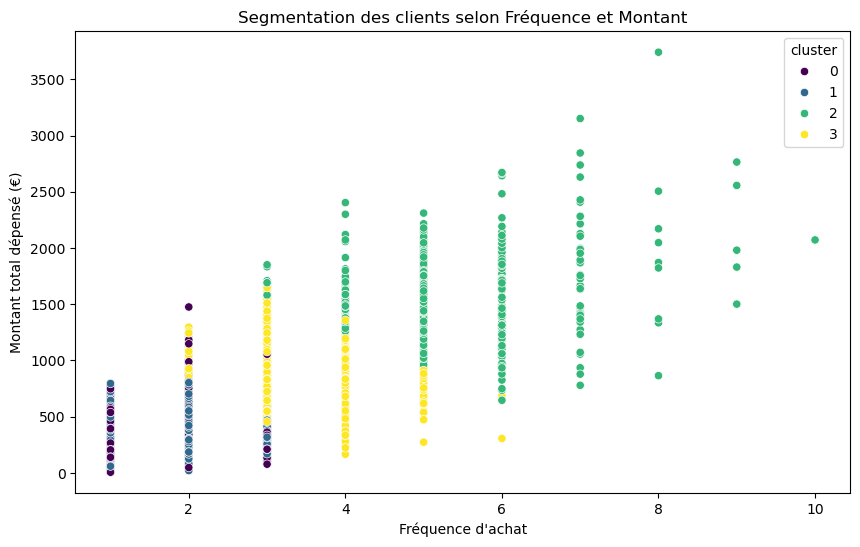

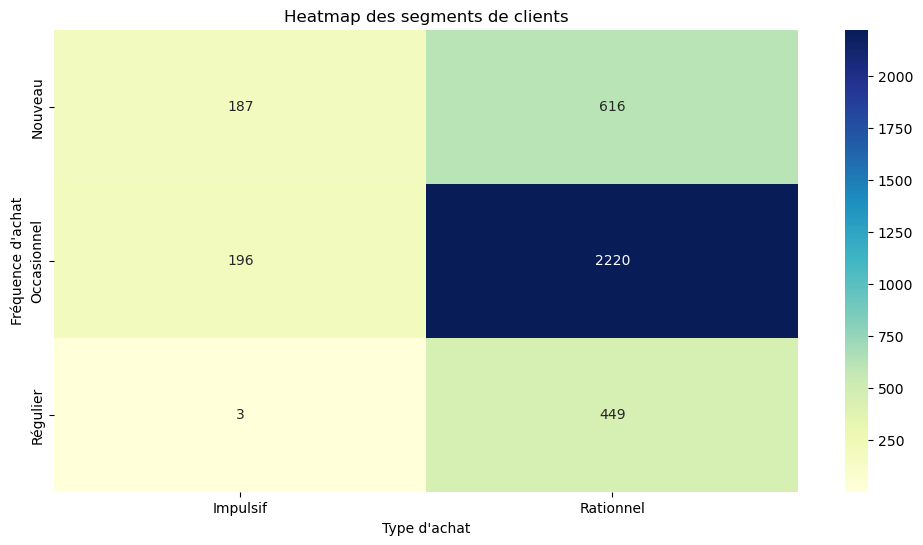

In [106]:
print(f"""
****************************************************************
*************************VISUALISATIONS*************************
****************************************************************
""")
# 1. Scatter plot des clients selon fréquence et montant dépensé
rfm_data_pd = rfm_data.select("Fréquence", "Montant", "cluster").toPandas()

# Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Fréquence", y="Montant", hue="cluster", data=rfm_data_pd, palette="viridis")
plt.title("Segmentation des clients selon Fréquence et Montant")
plt.xlabel("Fréquence d'achat")
plt.ylabel("Montant total dépensé (€)")
plt.show()

# 2. Heatmap des segments de clients
# Group by to aggregate the counts and avoid duplicates in pivot
segment_counts = rfm_data.groupBy("Segment_Fréquence", "Segment_Type_Achat", "Segment_Promotion").agg(
    count("Client_ID").alias("Nombre_Clients")
).orderBy("Segment_Fréquence", "Segment_Type_Achat", "Segment_Promotion")

# Convert to pandas dataframe
segment_counts_pd = segment_counts.toPandas()

# Make sure no duplicates exist before pivoting
segment_counts_agg = segment_counts_pd.groupby(["Segment_Fréquence", "Segment_Type_Achat"]).agg({"Nombre_Clients": "sum"}).reset_index()

# Pivot table for heatmap
pivot_table = segment_counts_agg.pivot(index="Segment_Fréquence", columns="Segment_Type_Achat", values="Nombre_Clients")

# Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Heatmap des segments de clients")
plt.xlabel("Type d'achat")
plt.ylabel("Fréquence d'achat")
plt.show()

# Arrêt de la session Spark
#spark.stop()